In [1]:
from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import glob
import os

path = '/content/drive/MyDrive/Colab Notebooks/Project Dog-Cat Neural Network Classification/Train_Data'

# Updated glob to ensure we find files correctly
dog_files = glob.glob(os.path.join(path, "dog", "*.jpg"))
cat_files = glob.glob(os.path.join(path, "cat", "*.jpg"))
files = dog_files + cat_files

print(f"Total Num of Images: {len(files)}")
total_num_of_images = len(files)

Total Num of Images: 1399


In [3]:
import numpy as np
import os
import shutil

# Define the full paths for the train and test directories
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

# Function to check if the dataset directories are effectively empty
def is_directory_empty(directory):
    if not os.path.exists(directory):
        return True
    for folder in ['dog', 'cat']:
        folder_path = os.path.join(directory, folder)
        if os.path.exists(folder_path) and os.listdir(folder_path):
            return False
    return True

# Check if folders are empty before proceeding
if is_directory_empty(train_dir) and is_directory_empty(test_dir):
    print("Destination folders are empty. Starting file copy...")

    # Create new train and test directories if they don't exist
    for t_dir in [train_dir, test_dir]:
        for folder_name in ['dog', 'cat']:
            os.makedirs(os.path.join(t_dir, folder_name), exist_ok=True)

    if total_num_of_images > 0:
        shuffle_index = np.random.permutation(total_num_of_images)

        # Split into Test (first 250)
        for i in shuffle_index[:250]:
            source_path = files[i]
            source_folder_name = source_path.split('/')[-2]
            image_name = os.path.basename(source_path)
            destination_path = os.path.join(test_dir, source_folder_name, image_name)
            shutil.copy(source_path, destination_path)

        # Split into Train (the rest)
        for i in shuffle_index[250:]:
            source_path = files[i]
            source_folder_name = source_path.split('/')[-2]
            image_name = os.path.basename(source_path)
            destination_path = os.path.join(train_dir, source_folder_name, image_name)
            shutil.copy(source_path, destination_path)

        print("Files copied successfully.")
    else:
        print("No files found to copy. Please check your source paths.")
else:
    print("Destination folders are not empty. Skipping copy to prevent duplicates.")

Destination folders are not empty. Skipping copy to prevent duplicates.


In [4]:
import torch
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
import os

# Define the transformation pipeline
my_transform = v2.Compose([
    v2.Resize((224,224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.12, 0.11, 0.40], [0.89, 0.21, 0.12])
])

# Base paths for train and test
# ImageFolder will automatically combine the 'cat' and 'dog' subfolders within these paths
train_path = '/content/drive/MyDrive/Colab Notebooks/Project Dog-Cat Neural Network Classification/Train_Data/train'
test_path = '/content/drive/MyDrive/Colab Notebooks/Project Dog-Cat Neural Network Classification/Train_Data/test'

train = ImageFolder(train_path, transform=my_transform)
test = ImageFolder(test_path, transform=my_transform)

print("Training Classes:", train.classes)
print("Training Class Mapping:", train.class_to_idx)
print(f"Total training images: {len(train)}")

print("\nTesting Classes:", test.classes)
print("Testing Class Mapping:", test.class_to_idx)
print(f"Total testing images: {len(test)}")

Training Classes: ['cat', 'dog']
Training Class Mapping: {'cat': 0, 'dog': 1}
Total training images: 1149

Testing Classes: ['cat', 'dog']
Testing Class Mapping: {'cat': 0, 'dog': 1}
Total testing images: 250


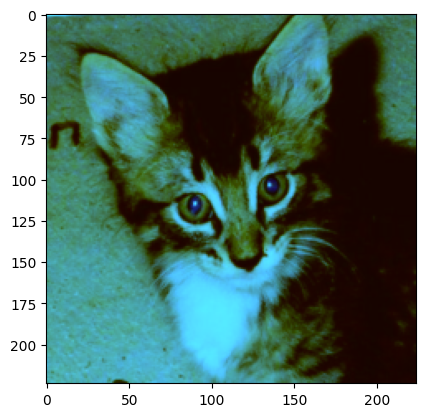

In [5]:
#For Data Visualisation

import matplotlib.pyplot as plt

def imshow(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.12, 0.12, 0.40])
    std = np.array([0.22, 0.20, 0.20])
    inp = std*inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)

imshow(train[30][0])


In [6]:
#Loading Pytorch tensors as Batches

train_data_generator = torch.utils.data.DataLoader(train, shuffle=True, batch_size=64, num_workers=2)
test_data_generator = torch.utils.data.DataLoader(test, batch_size=64, num_workers=2)


In [7]:
#Building Network Architecture

import torch.nn as nn
import torchvision.models
from torchvision.models import ResNet50_Weights


pretrained_resnet = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT) #ResNet50 has 50 layers that learn from weights (+ some number of non-learnable layers)

number_features = pretrained_resnet.fc.in_features

pretrained_resnet.fc = nn.Linear(number_features, 4)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


In [8]:
#Adapt the pretrained ResNet50 Model for Dog-Cat Classification

#To do this, we just need to change num_of_output_features in the final (and only) fully-connected layer to 4 [By default, ResNet only has 1 fully-connected layer, which will be the final layer]

pretrained_resnet.fc = nn.Linear(number_features, 4)


In [9]:
#Make use of GPU (if the machine we running from has GPU)

if torch.cuda.is_available():
    pretrained_resnet = pretrained_resnet.cuda()
    print("This model will run on GPU.")
else:
    print("This model will run on CPU.")


This model will run on GPU.


In [18]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.autograd import Variable

learning_rate = 0.005
criterion = nn.CrossEntropyLoss()
fit_optimizer = optim.SGD(pretrained_resnet.parameters(), lr=0.005, momentum=0.6)
exp_learning_rate_scheduler = lr_scheduler.StepLR(fit_optimizer, step_size=2, gamma=0.05)

def train_my_model(model, criterion, optimizer, scheduler, number_of_epochs=20):
    since = time.time()
    best_model_weights = model.state_dict()
    best_accuracy = 0.0
    for epoch in range(number_of_epochs):
        print('Epoch {}/{}'.format(epoch, number_of_epochs - 1))
        print('-' * 10)
        for each_phase in ['train', 'test']:
            if each_phase == 'train':
                model.train(True)
            else:
                model.train(False)

            running_loss = 0.0
            running_correct = 0

            for data in dataloaders[each_phase]:
                input_data, label_data = data
                if torch.cuda.is_available():
                    input_data = Variable(input_data.cuda())
                    label_data = Variable(label_data.cuda())
                else:
                    input_data, label_data = Variable(input_data), Variable(label_data)

                optimizer.zero_grad()
                outputs = model(input_data)
                _, preds = torch.max(outputs.data, 1)
                loss = criterion(outputs, label_data)

                if each_phase == 'train':
                    loss.backward()
                    optimizer.step()

                running_loss += loss.item()
                running_correct += torch.sum(preds == label_data).item()

            epoch_loss = running_loss / len(dataloaders[each_phase].dataset)
            epoch_acc = running_correct / len(dataloaders[each_phase].dataset)
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(each_phase, epoch_loss, epoch_acc))

            # Step the scheduler after the training phase
            if each_phase == 'train':
                scheduler.step()

            if each_phase == 'test' and epoch_acc > best_accuracy:
                best_accuracy = epoch_acc
                best_model_weights = model.state_dict()

    print()
    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_accuracy))
    model.load_state_dict(best_model_weights)
    return model

In [19]:
dataloaders = {
    'train': train_data_generator,
    'test': test_data_generator
}
train_my_model(pretrained_resnet, criterion, fit_optimizer, exp_learning_rate_scheduler, number_of_epochs=20)

Epoch 0/19
----------
train Loss: 0.0134 Acc: 0.7998
test Loss: 0.0071 Acc: 0.9800
Epoch 1/19
----------
train Loss: 0.0048 Acc: 0.9721
test Loss: 0.0035 Acc: 0.9840
Epoch 2/19
----------
train Loss: 0.0033 Acc: 0.9713
test Loss: 0.0034 Acc: 0.9760
Epoch 3/19
----------
train Loss: 0.0033 Acc: 0.9721
test Loss: 0.0034 Acc: 0.9760
Epoch 4/19
----------
train Loss: 0.0033 Acc: 0.9669
test Loss: 0.0033 Acc: 0.9760
Epoch 5/19
----------
train Loss: 0.0033 Acc: 0.9748
test Loss: 0.0034 Acc: 0.9760
Epoch 6/19
----------
train Loss: 0.0032 Acc: 0.9756
test Loss: 0.0034 Acc: 0.9760
Epoch 7/19
----------
train Loss: 0.0032 Acc: 0.9765
test Loss: 0.0034 Acc: 0.9760
Epoch 8/19
----------
train Loss: 0.0032 Acc: 0.9765
test Loss: 0.0034 Acc: 0.9760
Epoch 9/19
----------
train Loss: 0.0032 Acc: 0.9721
test Loss: 0.0033 Acc: 0.9760
Epoch 10/19
----------
train Loss: 0.0033 Acc: 0.9800
test Loss: 0.0034 Acc: 0.9760
Epoch 11/19
----------
train Loss: 0.0032 Acc: 0.9765
test Loss: 0.0033 Acc: 0.9760
Ep

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 